# Permission Risk Scoring & Classification — Lifestyle & Health

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)

RANDOM_STATE = 42
FLAG_QUANTILE = 0.85
CATEGORY = "Lifestyle & Health"
RESULTS_DIR = "results_Lifestyle_and_Health"
os.makedirs(RESULTS_DIR, exist_ok=True)
pd.set_option("display.max_rows", 20)

In [2]:
df = pd.read_csv("Android_Permission.csv")
df.shape

(29999, 184)

## 1. All Categories in the Dataset

In [3]:
df["Category"].value_counts()

Category
Entertainment        2827
Travel & Local       2154
Books & Reference    1959
Arcade & Action      1959
Brain & Puzzle       1873
                     ... 
Sports Games          341
Photography           297
Racing                288
Medical               270
Weather               173
Name: count, Length: 30, dtype: int64

## 2. Group into 6 Broad Categories

In [4]:
BROAD_CATEGORY_MAP = {
    "Arcade & Action": "Games", "Brain & Puzzle": "Games", "Casual": "Games",
    "Cards & Casino": "Games", "Sports Games": "Games", "Racing": "Games",
    "Social": "Social & Communication", "Communication": "Social & Communication",
    "News & Magazines": "Social & Communication",
    "Tools": "Productivity & Tools", "Business": "Productivity & Tools",
    "Finance": "Productivity & Tools", "Productivity": "Productivity & Tools",
    "Libraries & Demo": "Productivity & Tools",
    "Entertainment": "Entertainment & Media", "Media & Video": "Entertainment & Media",
    "Music & Audio": "Entertainment & Media", "Comics": "Entertainment & Media",
    "Photography": "Entertainment & Media",
    "Education": "Education & Reference", "Books & Reference": "Education & Reference",
    "Travel & Local": "Lifestyle & Health", "Personalization": "Lifestyle & Health",
    "Lifestyle": "Lifestyle & Health", "Health & Fitness": "Lifestyle & Health",
    "Sports": "Lifestyle & Health", "Transportation": "Lifestyle & Health",
    "Shopping": "Lifestyle & Health", "Medical": "Lifestyle & Health",
    "Weather": "Lifestyle & Health",
}
df["BroadCategory"] = df["Category"].map(BROAD_CATEGORY_MAP)
df["BroadCategory"].value_counts()

BroadCategory
Lifestyle & Health        8064
Games                     7020
Entertainment & Media     5044
Productivity & Tools      4625
Education & Reference     3264
Social & Communication    1982
Name: count, dtype: int64

## 3. Preprocessing — Remove Duplicates

In [5]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(27310, 185)

## 4. Map Real Permission Columns to the 12 Target Permissions

`CallLogs` and `ReadPhoneNumbers` don't exist in this dataset's taxonomy.

In [6]:
PERMISSION_COLUMN_MAP = {
    "Camera": ["Hardware controls : take pictures and videos (D)"],
    "Location": [
        "Your location : coarse (network-based) location (D)",
        "Your location : fine (GPS) location (D)",
        "Default : coarse (network-based) location (S)",
    ],
    "Contacts": [
        "Your personal information : read contact data (D)",
        "Your personal information : write contact data (D)",
        "Default : write contact data (S)",
        "Your accounts : contacts data in Google accounts (D)",
    ],
    "Microphone": ["Hardware controls : record audio (D)"],
    "Storage": [
        "Storage : modify/delete USB storage contents modify/delete SD card contents (D)",
        "Default : modify/delete USB storage contents modify/delete SD card contents (S)",
    ],
    "SMS": [
        "Services that cost you money : send SMS messages (D)",
        "Your messages : edit SMS or MMS (D)", "Your messages : read SMS or MMS (D)",
        "Your messages : receive SMS (D)", "Your messages : receive MMS (D)",
        "Your messages : send SMS-received broadcast (S)",
    ],
    "CallLogs": [],
    "Bluetooth": [
        "Network communication : create Bluetooth connections (D)",
        "System tools : bluetooth administration (D)",
    ],
    "Calendar": [
        "Your personal information : add or modify calendar events and send email to guests (D)",
        "Your personal information : read calendar events (D)",
    ],
    "PhoneState": [
        "Default : read phone state and identity (S)",
        "Phone calls : read phone state and identity (D)",
    ],
    "Internet": [
        "Default : full Internet access (S)",
        "Network communication : full Internet access (D)",
    ],
    "ReadPhoneNumbers": [],
}
PERMISSIONS = list(PERMISSION_COLUMN_MAP.keys())

perm_cols = {}
for target, sources in PERMISSION_COLUMN_MAP.items():
    valid = [c for c in sources if c in df.columns]
    perm_cols[target] = (df[valid].fillna(0).sum(axis=1) > 0).astype(int) if valid else pd.Series(0, index=df.index)
df = pd.concat([df, pd.DataFrame(perm_cols)], axis=1)

pd.Series({p: len(c) for p, c in PERMISSION_COLUMN_MAP.items()}, name="source_columns_used")

Camera              1
Location            3
Contacts            4
Microphone          1
Storage             2
SMS                 6
CallLogs            0
Bluetooth           2
Calendar            2
PhoneState          2
Internet            2
ReadPhoneNumbers    0
Name: source_columns_used, dtype: int64

## 5. Build Label and Proxy Risk Score

In [7]:
df["LabelEncoded"] = df["Class"].astype(int)
df["TrueLabel"] = df["LabelEncoded"].map({0: "Benign", 1: "Malicious"})

dpc = df["Dangerous permissions count"].astype(float).fillna(df["Dangerous permissions count"].median())
df["PrivacyRiskScore"] = (dpc - dpc.min()) / (dpc.max() - dpc.min() + 1e-9)

df[["TrueLabel", "PrivacyRiskScore"]].describe(include="all")

,TrueLabel,PrivacyRiskScore
count,27310,27310.000000
unique,2,NaN
top,Malicious,NaN
freq,18232,NaN
mean,NaN,0.100516
std,NaN,0.098926
min,NaN,0.000000
25%,NaN,0.033333
50%,NaN,0.066667
75%,NaN,0.133333


## 6. Select Category: Lifestyle & Health

In [8]:
cat_df = df[df["BroadCategory"] == CATEGORY].reset_index(drop=True)
print(f"{CATEGORY}: {len(cat_df)} apps")
cat_df["TrueLabel"].value_counts(normalize=True)

Lifestyle & Health: 7416 apps


TrueLabel
Malicious    0.781688
Benign       0.218312
Name: proportion, dtype: float64

## 7. Permission Rankings

In [9]:
N = len(PERMISSIONS)

def compute_rankings(data, permissions, label_col="LabelEncoded"):
    freq = data[permissions].sum()
    risk = pd.Series({p: data.loc[data[p] == 1, "PrivacyRiskScore"].mean() for p in permissions}).fillna(0)
    mal = pd.Series({p: data.loc[data[p] == 1, label_col].mean() for p in permissions}).fillna(0)
    return pd.DataFrame({
        "Permission": permissions,
        "Frequency": freq.values,
        "FrequencyRank": freq.rank(ascending=False, method="min").astype(int).values,
        "PrivacyRisk": risk.reindex(permissions).values,
        "PrivacyRank": risk.rank(ascending=False, method="min").astype(int).reindex(permissions).values,
        "MaliciousRate": mal.reindex(permissions).values,
        "MaliciousRank": mal.rank(ascending=False, method="min").astype(int).reindex(permissions).values,
    })

ranking_df = compute_rankings(cat_df, PERMISSIONS)
ranking_df

,Permission,Frequency,FrequencyRank,PrivacyRisk,PrivacyRank,MaliciousRate,MaliciousRank
0,Camera,668,5,0.212425,6,0.790419,5
1,Location,2883,2,0.184842,9,0.847728,3
2,Contacts,642,6,0.312461,4,0.827103,4
3,Microphone,255,8,0.375425,2,0.772549,9
4,Storage,2479,3,0.186204,8,0.776523,8
5,SMS,402,7,0.339303,3,0.883085,1
6,CallLogs,0,11,0.000000,11,0.000000,11
7,Bluetooth,177,9,0.445386,1,0.858757,2
8,Calendar,141,10,0.270922,5,0.787234,6
9,PhoneState,2033,4,0.199590,7,0.751599,10


## 8. Borda Score

In [10]:
def apply_borda(ranking_df, n):
    r = ranking_df.copy()
    r["BordaScore"] = (n - r["FrequencyRank"]) + (n - r["PrivacyRank"]) + (n - r["MaliciousRank"])
    r["BordaRank"] = r["BordaScore"].rank(ascending=False, method="min").astype(int)
    return r.sort_values("BordaRank")

borda_df = apply_borda(ranking_df, N)
borda_df[["Permission", "FrequencyRank", "PrivacyRank", "MaliciousRank", "BordaScore", "BordaRank"]]

,Permission,FrequencyRank,PrivacyRank,MaliciousRank,BordaScore,BordaRank
5,SMS,7,3,1,25,1
7,Bluetooth,9,1,2,24,2
1,Location,2,9,3,22,3
2,Contacts,6,4,4,22,3
0,Camera,5,6,5,20,5
10,Internet,1,10,7,18,6
4,Storage,3,8,8,17,7
3,Microphone,8,2,9,17,7
9,PhoneState,4,7,10,15,9
8,Calendar,10,5,6,15,9


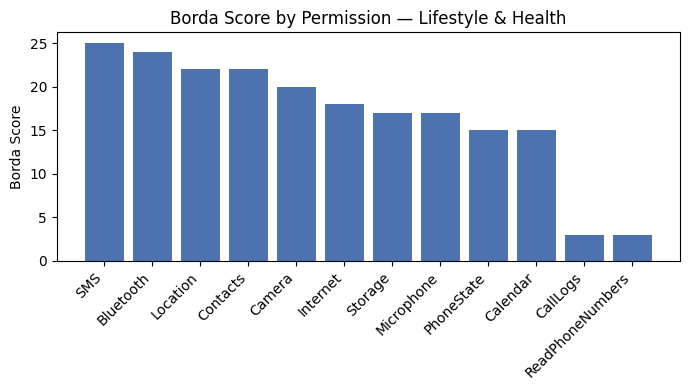

In [11]:
plt.figure(figsize=(7, 4))
plt.bar(borda_df["Permission"], borda_df["BordaScore"], color="#4C72B0")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Borda Score")
plt.title("Borda Score by Permission — Lifestyle & Health")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "borda_score.png"), dpi=120)
plt.show()

## 9. Garrett Score

In [12]:
GARRETT_PCT = np.array([2,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,98])
GARRETT_SCORE = np.array([82,75,70,66,63,60,57,54,51,48,45,42,39,36,33,30,27,24,20,15,10])

def garrett_score(rank, n):
    pct = 100 * (rank - 0.5) / n
    return np.interp(pct, GARRETT_PCT, GARRETT_SCORE)

def apply_garrett(ranking_df, n):
    r = ranking_df.copy()
    r["GarrettTotal"] = (
        r["FrequencyRank"].apply(lambda x: garrett_score(x, n))
        + r["PrivacyRank"].apply(lambda x: garrett_score(x, n))
        + r["MaliciousRank"].apply(lambda x: garrett_score(x, n))
    )
    r["GarrettRank"] = r["GarrettTotal"].rank(ascending=False, method="min").astype(int)
    return r.sort_values("GarrettRank")

garrett_df = apply_garrett(ranking_df, N)
garrett_df[["Permission", "FrequencyRank", "PrivacyRank", "MaliciousRank", "GarrettTotal", "GarrettRank"]]

,Permission,FrequencyRank,PrivacyRank,MaliciousRank,GarrettTotal,GarrettRank
5,SMS,7,3,1,181.944444,1
7,Bluetooth,9,1,2,177.444444,2
1,Location,2,9,3,163.000000,3
2,Contacts,6,4,4,162.500000,4
0,Camera,5,6,5,152.500000,5
10,Internet,1,10,7,146.944444,6
3,Microphone,8,2,9,138.000000,7
4,Storage,3,8,8,137.500000,8
9,PhoneState,4,7,10,127.500000,9
8,Calendar,10,5,6,127.500000,9


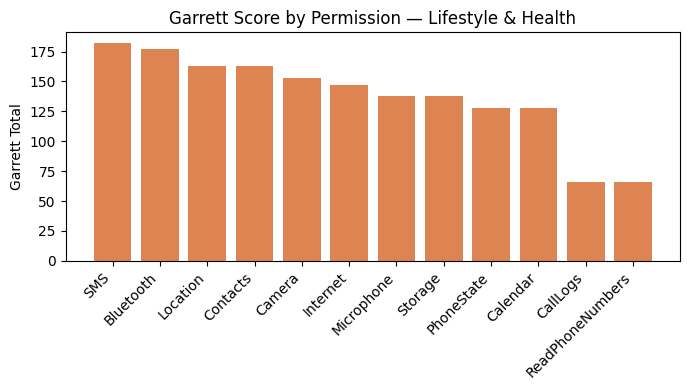

In [13]:
plt.figure(figsize=(7, 4))
plt.bar(garrett_df["Permission"], garrett_df["GarrettTotal"], color="#DD8452")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Garrett Total")
plt.title("Garrett Score by Permission — Lifestyle & Health")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "garrett_score.png"), dpi=120)
plt.show()

## 10. Normalized Risk Weights

In [14]:
def normalize_weights(garrett_df):
    w = garrett_df.set_index("Permission")["GarrettTotal"]
    return (w / w.sum()).sort_values(ascending=False)

weights = normalize_weights(garrett_df)
weights

Permission
SMS                 0.110481
Bluetooth           0.107749
Location            0.098978
Contacts            0.098674
Camera              0.092602
Internet            0.089228
Microphone          0.083797
Storage             0.083494
PhoneState          0.077421
Calendar            0.077421
CallLogs            0.040077
ReadPhoneNumbers    0.040077
Name: GarrettTotal, dtype: float64

## 11. Baseline Privacy Score & Classification

In [15]:
def baseline_score(data, permissions, weights):
    return sum(data[p] * weights[p] for p in permissions)

def classify(score):
    return "Low" if score < 0.33 else "Medium" if score < 0.66 else "High"

cat_df["BaselinePrivacyScore"] = baseline_score(cat_df, PERMISSIONS, weights)
cat_df["PrivacyClassification"] = cat_df["BaselinePrivacyScore"].apply(classify)
cat_df["PrivacyClassification"].value_counts()

PrivacyClassification
Low       6025
Medium    1285
High       106
Name: count, dtype: int64

## 12. Baseline Evaluation

In [16]:
def evaluate(y_true, scores, threshold=0.5):
    preds = (scores >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, preds),
        "Precision": precision_score(y_true, preds, zero_division=0),
        "Recall": recall_score(y_true, preds, zero_division=0),
        "F1": f1_score(y_true, preds, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, scores) if y_true.nunique() > 1 else float("nan"),
    }

baseline_metrics = evaluate(cat_df["LabelEncoded"], cat_df["BaselinePrivacyScore"])
pd.Series(baseline_metrics, name="Borda+Garrett Baseline")

Accuracy     0.245820
Precision    0.824841
Recall       0.044678
F1           0.084765
ROC-AUC      0.528369
Name: Borda+Garrett Baseline, dtype: float64

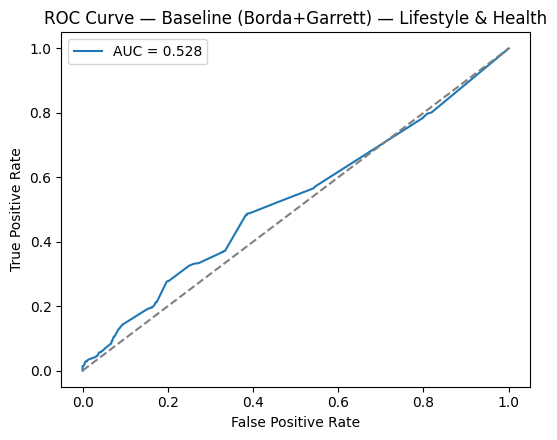

In [17]:
fpr, tpr, _ = roc_curve(cat_df["LabelEncoded"], cat_df["BaselinePrivacyScore"])
plt.figure(figsize=(5.5, 4.5))
plt.plot(fpr, tpr, label=f"AUC = {baseline_metrics['ROC-AUC']:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline (Borda+Garrett) — Lifestyle & Health")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "roc_baseline.png"), dpi=120)
plt.show()

## 13. Disagreement Rule

In [18]:
def flag_disagreements(data, scores, quantile=0.85):
    disagreement = (scores - data["LabelEncoded"]).abs()
    threshold = disagreement.quantile(quantile)
    flagged = data.loc[disagreement >= threshold, ["App", "Package", "Category", "TrueLabel"]].copy()
    flagged["Score"] = scores[disagreement >= threshold]
    flagged["Disagreement"] = disagreement[disagreement >= threshold]
    return flagged.sort_values("Disagreement", ascending=False)

flagged = flag_disagreements(cat_df, cat_df["BaselinePrivacyScore"], FLAG_QUANTILE)
print(f"Flagged: {len(flagged)} apps ({len(flagged)/len(cat_df)*100:.1f}% of category)")
flagged.head(15)

Flagged: 1151 apps (15.5% of category)


,App,Package,Category,TrueLabel,Score,Disagreement
7407,TV Static Live Wallpaper,com.custom.lwp.static,Personalization,Malicious,0.0,1.0
15,MedCalc 3000 Neurology,com.medcalc3000.neurology,Medical,Malicious,0.0,1.0
16,Sea animals/Amphibious animal,jp.co.scale.h24.amphibious,Lifestyle,Malicious,0.0,1.0
23,GroceryList,net.sroz.grocerylist,Shopping,Malicious,0.0,1.0
25,Titans Live Wallpaper PRO,com.dankei.titanslwpro,Sports,Malicious,0.0,1.0
36,aHome/Open Home Zebra Theme,mobi.bbase.ahome.theme.zebra,Personalization,Malicious,0.0,1.0
46,Turkey Disguise Live Wallpaper,com.custom.lwp.thankdisxx,Personalization,Malicious,0.0,1.0
47,Crocodile Live Wallpaper,com.custom.lwp.LWPcrocodile,Personalization,Malicious,0.0,1.0
50,Breakfast Recipes Cookbook,com.EaseApps.breakfastrecipes,Lifestyle,Malicious,0.0,1.0
55,aHome/Open Home Glow Theme,mobi.bbase.ahome.theme.Glow,Personalization,Malicious,0.0,1.0


In [19]:
flagged.to_csv(os.path.join(RESULTS_DIR, "flagged_apps.csv"), index=False)
weights.to_csv(os.path.join(RESULTS_DIR, "risk_weights.csv"))
print("Saved: flagged_apps.csv, risk_weights.csv")

Saved: flagged_apps.csv, risk_weights.csv


## 14. Classifiers — Feature Preparation

In [20]:
EXTRA_FEATURES = ["Rating", "Number of ratings", "Price", "Dangerous permissions count", "Safe permissions count"]
FEATURE_COLS = PERMISSIONS + EXTRA_FEATURES

for c in EXTRA_FEATURES:
    cat_df[c] = pd.to_numeric(cat_df[c], errors="coerce").fillna(0)

X = cat_df[FEATURE_COLS].values
y = cat_df["LabelEncoded"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (5932, 17), Test: (1484, 17)


## 15. Decision Tree Classifier

In [21]:
dt_clf = DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=RANDOM_STATE)
dt_clf.fit(X_train, y_train)
dt_pred = dt_clf.predict(X_test)
dt_proba = dt_clf.predict_proba(X_test)[:, 1]

dt_metrics = evaluate(pd.Series(y_test), dt_proba)
pd.Series(dt_metrics, name="Decision Tree")

Accuracy     0.770889
Precision    0.928870
Recall       0.765517
F1           0.839319
ROC-AUC      0.855842
Name: Decision Tree, dtype: float64

In [22]:
confusion_matrix(y_test, dt_pred)

array([[256,  68],
       [272, 888]])

## 16. Random Forest Classifier

In [23]:
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=RANDOM_STATE)
rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_test)
rf_proba = rf_clf.predict_proba(X_test)[:, 1]

rf_metrics = evaluate(pd.Series(y_test), rf_proba)
pd.Series(rf_metrics, name="Random Forest")

Accuracy     0.768194
Precision    0.942516
Recall       0.749138
F1           0.834774
ROC-AUC      0.874661
Name: Random Forest, dtype: float64

In [24]:
confusion_matrix(y_test, rf_pred)

array([[271,  53],
       [291, 869]])

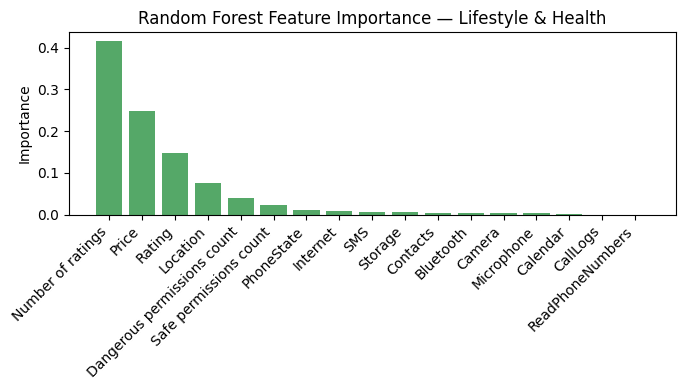

In [25]:
importances = pd.Series(rf_clf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
plt.figure(figsize=(7, 4))
plt.bar(importances.index, importances.values, color="#55A868")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance — Lifestyle & Health")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "rf_feature_importance.png"), dpi=120)
plt.show()

## 17. AdaBoost Classifier

In [26]:
ada_clf = AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE)
ada_clf.fit(X_train, y_train)
ada_pred = ada_clf.predict(X_test)
ada_proba = ada_clf.predict_proba(X_test)[:, 1]

ada_metrics = evaluate(pd.Series(y_test), ada_proba)
pd.Series(ada_metrics, name="AdaBoost")

Accuracy     0.825472
Precision    0.870173
Recall       0.912931
F1           0.891039
ROC-AUC      0.857689
Name: AdaBoost, dtype: float64

In [27]:
confusion_matrix(y_test, ada_pred)

array([[ 166,  158],
       [ 101, 1059]])

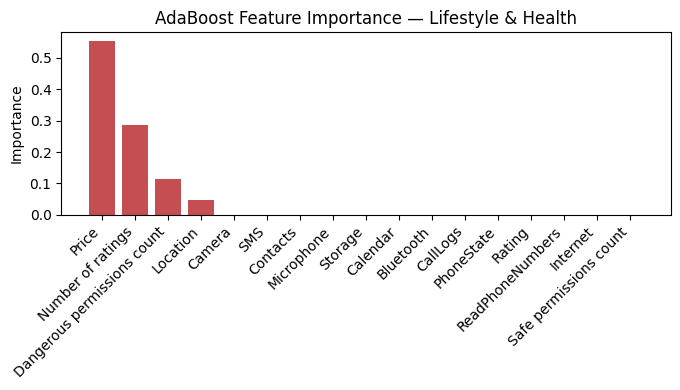

In [28]:
ada_importances = pd.Series(ada_clf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
plt.figure(figsize=(7, 4))
plt.bar(ada_importances.index, ada_importances.values, color="#C44E52")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Importance")
plt.title("AdaBoost Feature Importance — Lifestyle & Health")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "adaboost_feature_importance.png"), dpi=120)
plt.show()

## 18. SVM Classifier

Uses scaled features, since SVM is distance-based.

In [29]:
svm_clf = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE)
svm_clf.fit(X_train_scaled, y_train)
svm_pred = svm_clf.predict(X_test_scaled)
svm_proba = svm_clf.predict_proba(X_test_scaled)[:, 1]

svm_metrics = evaluate(pd.Series(y_test), svm_proba)
pd.Series(svm_metrics, name="SVM")

Accuracy     0.784367
Precision    0.784939
Recall       0.997414
F1           0.878512
ROC-AUC      0.805417
Name: SVM, dtype: float64

In [30]:
confusion_matrix(y_test, svm_pred)

array([[272,  52],
       [439, 721]])

## 19. ROC Curve — All Classifiers

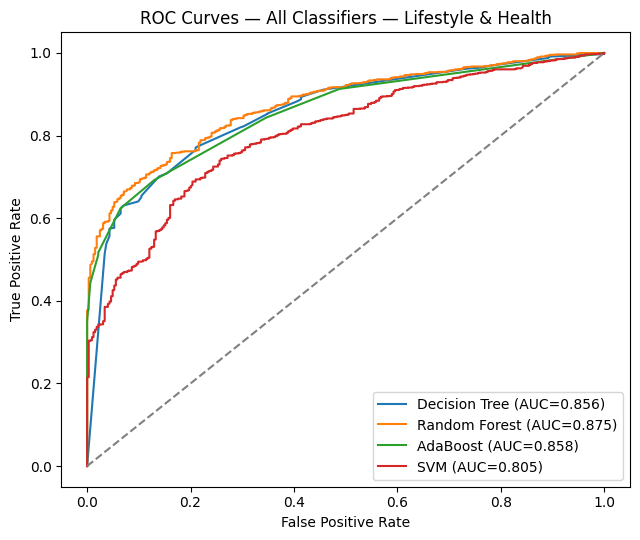

In [31]:
plt.figure(figsize=(6.5, 5.5))
for name, proba in [("Decision Tree", dt_proba), ("Random Forest", rf_proba),
                     ("AdaBoost", ada_proba), ("SVM", svm_proba)]:
    fpr_c, tpr_c, _ = roc_curve(y_test, proba)
    auc_c = roc_auc_score(y_test, proba)
    plt.plot(fpr_c, tpr_c, label=f"{name} (AUC={auc_c:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Classifiers — Lifestyle & Health")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "roc_all_classifiers.png"), dpi=120)
plt.show()

## 20. Final Comparison — Baseline vs All Classifiers

In [32]:
comparison = pd.DataFrame({
    "Borda+Garrett Baseline": baseline_metrics,
    "Decision Tree": dt_metrics,
    "Random Forest": rf_metrics,
    "AdaBoost": ada_metrics,
    "SVM": svm_metrics,
}).round(4)
comparison

,Borda+Garrett Baseline,Decision Tree,Random Forest,AdaBoost,SVM
Accuracy,0.2458,0.7709,0.7682,0.8255,0.7844
Precision,0.8248,0.9289,0.9425,0.8702,0.7849
Recall,0.0447,0.7655,0.7491,0.9129,0.9974
F1,0.0848,0.8393,0.8348,0.8910,0.8785
ROC-AUC,0.5284,0.8558,0.8747,0.8577,0.8054


In [33]:
comparison.to_csv(os.path.join(RESULTS_DIR, "classifier_comparison.csv"))
print(f"All results saved to: {RESULTS_DIR}/")
print(os.listdir(RESULTS_DIR))

All results saved to: results_Lifestyle_and_Health/
['adaboost_feature_importance.png', 'borda_score.png', 'classifier_comparison.csv', 'flagged_apps.csv', 'garrett_score.png', 'rf_feature_importance.png', 'risk_weights.csv', 'roc_all_classifiers.png', 'roc_baseline.png']
